In [3]:
import meta
import load

In [33]:
records = []

dataset = meta.datasets[0]
records.extend(load.load_dataset(dataset))

dateset = meta.datasets[1]
records.extend(load.load_dataset(dateset))

 11%|█         | 5/45 [00:00<00:02, 18.42it/s]

Error processing record 102-0: [Errno 2] No such file or directory: 'c:/Users/wuyan/Projects/wfdb-python/mitdb/102-0.hea'


100%|██████████| 45/45 [00:03<00:00, 14.36it/s]


Loaded 44 records from mitdb dataset.


  0%|          | 0/25 [00:00<?, ?it/s]

Error processing record 00735: sampto must be greater than sampfrom
Error processing record 03665: sampto must be greater than sampfrom


100%|██████████| 25/25 [00:20<00:00,  1.20it/s]

Loaded 23 records from afdb dataset.


### Check all Annotations

In [34]:
# loop through all records, counts the number of AFib/AFlutter/Others in df_ann
annotations = []
for record in records:
    df_ann = record['df_ann']
    annotations.extend(df_ann['AuxNote'].tolist())

from collections import Counter
counter = Counter(annotations)
print(counter)

Counter({'(N': 794, 'MISSB': 428, '(AFIB': 374, '(B': 212, '(PREX': 103, '(T': 83, '(VT': 60, '(AFL': 59, '(NOD': 36, '(SVTA': 26, '(J': 12, '(VFL': 6, 'TS': 6, '(BII': 5, '(IVR': 4, 'PSE': 3, '(AB': 3, '(SBR': 1})


## Preprocess Data

In [35]:
from preprocess import bandpass_filtering, frequency_resampling, merge_annotation_to_wave, cut_by_moving_window, populate_label, preprocess_records, generate_inputs_from_samples, generate_samples_from_records
import numpy as np

In [36]:
window_duration = 20  # seconds
stride_duration = 20  # seconds
records = preprocess_records(records, frequency_resample=True, bandpass_filter=True)
samples = generate_samples_from_records(records, window_duration=window_duration, stride_duration=stride_duration)
X_data, Y_data = generate_inputs_from_samples(samples)
X, Y = X_data.copy(), Y_data.copy()

100%|██████████| 46126/46126 [00:16<00:00, 2747.45it/s]


X shape: (46126, 4000) y shape: (46126, 20)


## Sanity Check (X, Y)

In [37]:
# map Y matrix (n_sample, n_seconds) to majority label vecotr (n_sample,)
def get_majority_label(Y):
    Y_majority = []
    for i in range(len(Y)):
        Y_majority.append(np.bincount(Y[i]).argmax())
    return np.array(Y_majority)


# count the number of occurrences of each label
counter = Counter(Y.reshape(-1))
print("Total label in Y counted as", counter)

Y_majority = get_majority_label(Y)
print("Majority label in Y counted as", Counter(Y_majority))

Total label in Y counted as Counter({0: 571993, 1: 343882, 2: 6645})
Majority label in Y counted as Counter({0: 28625, 1: 17176, 2: 325})


## Prepare for Training

In [38]:
from preprocess import class_to_onehot, onehot_to_class
print("Before label conversion Y shape:", Y.shape)
Y = class_to_onehot(Y, num_classes=3)
print("After label conversion Y shape:", Y.shape)

Before label conversion Y shape: (46126, 20)
After label conversion Y shape: (46126, 60)


In [ ]:
# # split the X,y data into train and test sets using stratified sampling on Y
# from sklearn.model_selection import train_test_split
# SEED = 42
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y_majority, random_state=SEED) # stratified sampling on Y_majority

# from sklearn.utils.class_weight import compute_class_weight
# class_weights = dict(enumerate(compute_class_weight(class_weight='balanced', classes=np.unique(Y_majority), y=Y_majority)))  
# class_weights = {k: v / sum(class_weights.values()) for k, v in class_weights.items()} # normalize the weights to sum to 1
# print("Class Weights:", class_weights)

In [39]:
# sample equal number of samples for each class based on Y_majority
from sklearn.utils import resample
SEED = 42
n_samples = 325
X_resampled, Y_resampled = [], []
for label in np.unique(Y_majority):
    X_label = X[Y_majority == label]
    Y_label = Y[Y_majority == label]
    X_resampled_label, Y_resampled_label = resample(X_label, Y_label, n_samples=n_samples, random_state=SEED) # resample to 1000 samples for each label
    X_resampled.append(X_resampled_label)
    Y_resampled.append(Y_resampled_label)
X_resampled = np.concatenate(X_resampled, axis=0)
Y_resampled = np.concatenate(Y_resampled, axis=0)
print("X_resampled shape:", X_resampled.shape)

# split the X, Y data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, random_state=SEED) # stratified sampling on Y_majority
class_weights = {0:1/3, 1:1/3, 2:1/3} # normalize the weights to sum to 1
print("Class Weights:", class_weights)

X_resampled shape: (975, 4000)
Class Weights: {0: 0.3333333333333333, 1: 0.3333333333333333, 2: 0.3333333333333333}


In [41]:
from tensorflow.keras.layers import Input, Dense, Conv1D, GlobalAveragePooling1D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

def network(X_train, y_train, X_test, y_test,
             unit_size, class_size, class_weights,
             learning_rate=0.001, batch_size = 32, epochs=40, 
             loss_type='cross_entropy', modelCheckPoint=False):    
    ####################################################################
    output_size = unit_size * class_size  # output size is the number of classes times the number of units
    print("Class Weights:", class_weights)
    
    def custom_loss(y_true, y_pred):
        if class_size != len(class_weights):
            raise ValueError("The length of class_weights must match the number of classes.")
        
        # Reshape tensors
        y_true = tf.reshape(y_true, [-1, unit_size, class_size])
        y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])

        loss = 0.0
        if loss_type == 'cross_entropy':
            for i in range(len(class_weights)):
                if class_weights[i] > 0:
                    loss += class_weights[i] * tf.reduce_mean(
                        -y_true[:, :, i] * tf.math.log(y_pred[:, :, i] + 1e-15) # average loss across all samples and units
                    )
        elif loss_type == 'mse':
            for i in range(len(class_weights)):
                if class_weights[i] > 0:
                    loss += class_weights[i] * tf.reduce_mean(
                        tf.square(y_true[:, :, i] - y_pred[:, :, i])  # average loss across all samples and units
                    )
        else:
            raise ValueError("Invalid loss type. Use 'cross_entropy' or 'mse'.")
        return loss

    def custom_accuracy(y_true, y_pred):
        y_true = tf.reshape(y_true, [-1, unit_size, class_size])
        y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])
        correct_predictions = tf.equal(tf.argmax(y_true, axis=2), tf.argmax(y_pred, axis=2))
        return tf.reduce_mean(tf.cast(correct_predictions, tf.float32)) # average accuracy across all samples and units

    ####################################################################
    inputs_cnn = Input(shape=(X_train.shape[1], 1))

    # Block 1
    x = Conv1D(16, kernel_size=7, padding='same')(inputs_cnn)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Block 2
    x = Conv1D(32, kernel_size=5, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(0.2)(x)
    x = Conv1D(32, kernel_size=3, padding='same')(x)

    # Block 3
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv1D(64, kernel_size=3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(0.2)(x)
    x = Conv1D(64, kernel_size=3, padding='same')(x)

    # Final block
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = GlobalAveragePooling1D()(x)

    # Output layer
    outputs_cnn = Dense(output_size, activation='softmax')(x)

    optimizer = Adam(learning_rate=learning_rate)
    model = Model(inputs=inputs_cnn, outputs=outputs_cnn)
    model.compile(optimizer=optimizer, loss=custom_loss, metrics=[custom_accuracy])

    # define callbacks for early stopping and saving the best model with lowest validation loss
    callbacks = [EarlyStopping(monitor='val_loss', patience=8)]
    if modelCheckPoint:
        callbacks.append(ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True))
    history=model.fit(X_train, y_train, epochs=epochs, 
                      callbacks=callbacks, batch_size=batch_size, validation_data=(X_test, y_test),
                      #class_weight=class_weights # assign class weights to the model 
                      ) 
    if modelCheckPoint:
        model.load_weights('best_model.h5')
    return (model, history)

In [42]:
model, history=network(X_train, Y_train, X_test, Y_test,
                      unit_size=window_duration, class_size=3, class_weights=class_weights,
                      learning_rate=0.0001, batch_size=32, epochs=100, loss_type='cross_entropy', modelCheckPoint=False)

Class Weights: {0: 0.3333333333333333, 1: 0.3333333333333333, 2: 0.3333333333333333}
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 423ms/step - custom_accuracy: 0.3218 - loss: 1.3776 - val_custom_accuracy: 0.3609 - val_loss: 1.3646
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 460ms/step - custom_accuracy: 0.3456 - loss: 1.3696 - val_custom_accuracy: 0.3359 - val_loss: 1.3647
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 399ms/step - custom_accuracy: 0.3735 - loss: 1.3643 - val_custom_accuracy: 0.3455 - val_loss: 1.3646
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 380ms/step - custom_accuracy: 0.4115 - loss: 1.3584 - val_custom_accuracy: 0.3534 - val_loss: 1.3641
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 370ms/step - custom_accuracy: 0.4510 - loss: 1.3546 - val_custom_accuracy: 0.3440 - val_loss: 1.3631
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 366ms/step - custom_accuracy: 0.4757 - loss: 1.3497 - val_custom_accuracy: 0.3524 - val_loss: 1.3613
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 361ms/step 

### Error Analysis

In [43]:
from analysis import plot_accuracy_and_loss, plot_confusion_matrix
from sklearn.metrics import confusion_matrix

In [44]:
import matplotlib.pyplot as plt
def plot_accuracy_and_loss(history, X_test, y_test, model, accuracy_keys = ['custom_accuracy', 'val_custom_accuracy'], loss_keys = ['loss', 'val_loss']):
    scores = model.evaluate((X_test), y_test, verbose=0)
    print("Accuracy: %.2f%%" % (scores[1]*100))
    
    print(history)
    fig1, ax_acc = plt.subplots()
    plt.plot(history.history[accuracy_keys[0]])
    plt.plot(history.history[accuracy_keys[1]])
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Model - Accuracy')
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()
    
    fig2, ax_loss = plt.subplots()
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Model- Loss')
    plt.legend(['Training', 'Validation'], loc='upper right')
    plt.plot(history.history[loss_keys[0]])
    plt.plot(history.history[loss_keys[1]])
    plt.show()


Accuracy: 79.35%


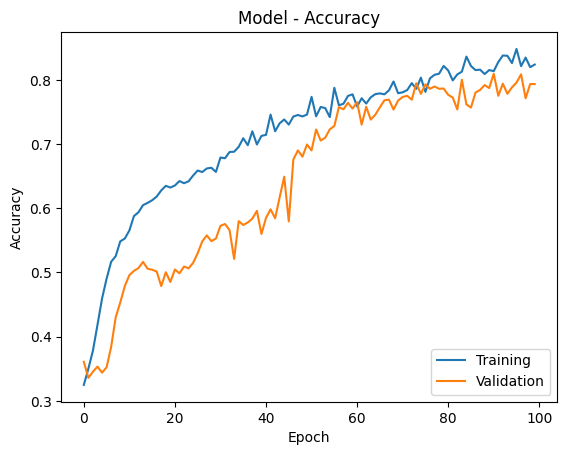

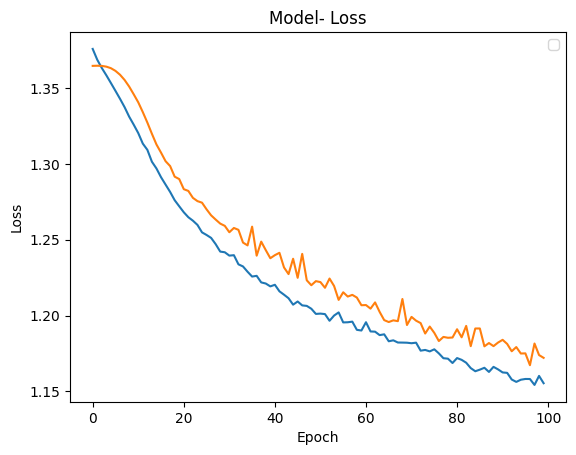

In [45]:
plot_accuracy_and_loss(history, X_test, Y_test, model)

In [46]:
Y_pred_onehot = model.predict(X_test)
Y_pred_class = onehot_to_class(Y_pred_onehot, num_classes=3)
Y_test_onehot = Y_test.copy()
Y_test_class = onehot_to_class(Y_test_onehot, num_classes=3)

# calculate the accuracy for each class
for i in range(3):
    acc = np.sum((Y_test_class == i) & (Y_pred_class == i)) / np.sum(Y_test_class == i)
    print(f"Accuracy for class {i}: {acc:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
Accuracy for class 0: 0.67
Accuracy for class 1: 0.81
Accuracy for class 2: 0.97


In [47]:
# calculate the confusion matrix based on Y_test_class and Y_pred_class
C = np.zeros((3, 3))
for i in range(len(Y_test_class)):
    for j in range(len(Y_test_class[i])):
        C[int(Y_test_class[i][j]), int(Y_pred_class[i][j])] += 1
print("Confusion Matrix:")
print(C)

Confusion Matrix:
[[ 842.  390.   24.]
 [  47. 1201.  231.]
 [   0.   40. 1125.]]


In [17]:
y_pred=model.predict(X_test)
cnf_matrix = confusion_matrix(Y_test, y_pred.argmax(axis=1))
plot_confusion_matrix(cnf_matrix, classes=['N', 'AFib', 'AFlu'], normalize=True)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets